## Federal Employment Agency API (factory shift sizes, local employment rates)
We will first get the employment rates from the BA REST API

### Pull Job Supply for Top 10 German Cities

This cell calls the Federal Employment Agency Job API for:
- Berlin
- Hamburg
- Muenchen
- Koeln
- Frankfurt am Main
- Stuttgart
- Duesseldorf
- Leipzig
- Dortmund
- Essen

It paginates through all matching jobs and builds:
1. A detailed job-level dataset
2. A city-level supply summary for modeling inputs

In [1]:
from pathlib import Path
import time
import requests
import pandas as pd
from typing import List, Dict

BASE_URL = "https://rest.arbeitsagentur.de/jobboerse/jobsuche-service/pc/v4/app/jobs"
HEADERS = {
    "accept": "application/json",
    "x-api-key": "jobboerse-jobsuche",
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
}

CITY_CONFIG = {
    "Berlin": {"query": "Berlin", "sub_areas": ["Berlin Mitte", "Berlin Neukoelln", "Berlin Tempelhof", "Berlin Spandau", "Berlin Reinickendorf"]},
    "Hamburg": {"query": "Hamburg", "sub_areas": ["Hamburg Mitte", "Hamburg Altona", "Hamburg Wandsbek", "Hamburg Harburg"]},
    "Munich": {"query": "Muenchen", "sub_areas": ["Muenchen", "Muenchen Stadtmitte", "Muenchen Schwabing"]},
    "Cologne": {"query": "Koeln", "sub_areas": ["Koeln", "Koeln Innenstadt", "Koeln Deutz"]},
    "Frankfurt": {"query": "Frankfurt am Main", "sub_areas": ["Frankfurt am Main"]},
    "Stuttgart": {"query": "Stuttgart", "sub_areas": ["Stuttgart"]},
    "Dusseldorf": {"query": "Duesseldorf", "sub_areas": ["Duesseldorf"]},
    "Leipzig": {"query": "Leipzig", "sub_areas": ["Leipzig"]},
    "Dortmund": {"query": "Dortmund", "sub_areas": ["Dortmund"]},
    "Essen": {"query": "Essen", "sub_areas": ["Essen"]},
}

INDUSTRIAL_KEYWORDS = [
    "produktion", "fertigung", "industrie", "anlage", "maschinen", "werk", 
    "schicht", "operator", "instandhaltung", "chemie", "metall", "montage",
    "schweißer", "fräser", "dreher", "lagerist"
]

OUTPUT_COLUMNS = [
    "city_label", "area_query", "title", "occupation", "reference", "employer",
    "publication_date", "postal_code", "city_returned", "region", "lat", "lon",
    "is_industrial"
]

def fetch_jobs(params: dict, pause: float = 0.2, max_pages: int = 300) -> List[dict]:
    jobs = []
    page = 1

    while page <= max_pages:
        req_params = params.copy()
        req_params["page"] = page

        try:
            response = requests.get(BASE_URL, headers=HEADERS, params=req_params, timeout=30)
            
            if response.status_code == 400:
                break  # API says no more pages
            if response.status_code == 429:
                print("Rate limit hit - waiting 5s...")
                time.sleep(5)
                continue
                
            response.raise_for_status()
            payload = response.json()

            page_jobs = payload.get("stellenangebote", [])
            if not page_jobs:
                break

            for item in page_jobs:
                arbeitsort = item.get("arbeitsort", {}) or {}
                coords = arbeitsort.get("koordinaten", {}) or {}
                title = item.get("titel", "")
                occupation = item.get("beruf", "")
                text_blob = f"{title} {occupation}".lower()

                is_industrial = any(kw in text_blob for kw in INDUSTRIAL_KEYWORDS)

                jobs.append({
                    "city_label": params.get("city_label"),
                    "area_query": params.get("area_query"),
                    "title": title,
                    "occupation": occupation,
                    "reference": item.get("refnr"),
                    "employer": item.get("arbeitgeber"),
                    "publication_date": item.get("aktuelleVeroeffentlichungsdatum"),
                    "postal_code": arbeitsort.get("plz"),
                    "city_returned": arbeitsort.get("ort"),
                    "region": arbeitsort.get("region"),
                    "lat": coords.get("lat"),
                    "lon": coords.get("lon"),
                    "is_industrial": is_industrial,
                })

            # Check if we reached the end
            size = int(payload.get("size", 100))
            total = int(payload.get("maxErgebnisse", 0))
            if page * size >= total:
                break

            page += 1
            time.sleep(pause)

        except Exception as e:
            print(f"Error on page {page}: {e}")
            break

    return jobs


def collect_all_jobs() -> List[dict]:
    all_jobs = []
    
    for city_label, config in CITY_CONFIG.items():
        base_query = config["query"]
        sub_areas = config.get("sub_areas", [base_query])
        
        print(f"\n🔍 Processing {city_label}...")
        
        for area in sub_areas:
            params = {
                "city_label": city_label,
                "area_query": area,
                "wo": area,
                "umkreis": 30,          # radius in km
                "size": 100,            # max allowed
                "arbeitszeit": "vz",    # Vollzeit (optional - remove if you want all)
                # "veroeffentlichtseit": "30"  # last 30 days - uncomment if needed
            }
            
            print(f"   → Sub-area: {area}", end=" ")
            area_jobs = fetch_jobs(params)
            all_jobs.extend(area_jobs)
            print(f"({len(area_jobs)} jobs)")
            
            time.sleep(0.5)  # polite delay between sub-areas

    return all_jobs


# ============== RUN ==============
print("Starting enhanced job collection for 10 cities...")
all_records = collect_all_jobs()

jobs_df = pd.DataFrame(all_records)

# === AGGREGATION ===
summary_df = (
    jobs_df.groupby(["city_label", "area_query"], dropna=False)
    .agg(
        total_jobs=("reference", "count"),
        industrial_jobs=("is_industrial", "sum"),
        unique_employers=("employer", "nunique"),
    )
    .reset_index()
)

summary_df["industrial_share_pct"] = (
    100.0 * summary_df["industrial_jobs"] / summary_df["total_jobs"].clip(lower=1)
).round(2)

summary_df = summary_df.sort_values(["city_label", "total_jobs"], ascending=[True, False])

# === SAVE ===
output_root = Path("../data")
raw_dir = output_root / "raw"
processed_dir = output_root / "processed"
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

jobs_df.to_csv(raw_dir / "ba_jobs_raw_detailed.csv", index=False)
summary_df.to_csv(processed_dir / "ba_jobs_supply_summary.csv", index=False)

print("\n✅ Done!")
print(f"Total jobs collected: {len(jobs_df):,}")
print("\nSummary:")
print(summary_df[["city_label", "area_query", "total_jobs", "industrial_jobs", "industrial_share_pct"]])

Starting enhanced job collection for 10 cities...

🔍 Processing Berlin...
   → Sub-area: Berlin Mitte (10000 jobs)
   → Sub-area: Berlin Neukoelln (10000 jobs)
   → Sub-area: Berlin Tempelhof (10000 jobs)
   → Sub-area: Berlin Spandau (10000 jobs)
   → Sub-area: Berlin Reinickendorf (10000 jobs)

🔍 Processing Hamburg...
   → Sub-area: Hamburg Mitte (10000 jobs)
   → Sub-area: Hamburg Altona (10000 jobs)
   → Sub-area: Hamburg Wandsbek (10000 jobs)
   → Sub-area: Hamburg Harburg (10000 jobs)

🔍 Processing Munich...
   → Sub-area: Muenchen (0 jobs)
   → Sub-area: Muenchen Stadtmitte (0 jobs)
   → Sub-area: Muenchen Schwabing (0 jobs)

🔍 Processing Cologne...
   → Sub-area: Koeln (0 jobs)
   → Sub-area: Koeln Innenstadt (0 jobs)
   → Sub-area: Koeln Deutz (2462 jobs)

🔍 Processing Frankfurt...
   → Sub-area: Frankfurt am Main (10000 jobs)

🔍 Processing Stuttgart...
   → Sub-area: Stuttgart (10000 jobs)

🔍 Processing Dusseldorf...
   → Sub-area: Duesseldorf (0 jobs)

🔍 Processing Leipzig..

In [2]:
jobs_df.head()

,city_label,area_query,title,occupation,reference,employer,publication_date,postal_code,city_returned,region,lat,lon,is_industrial
0,Berlin,Berlin Mitte,Duales Studium Hotelmanagement (m/w/d),Assistent/in - Hotelmanagement,12518-0UJ2TU-27Z-S,Motel One Berlin - Hackescher Markt,2026-05-24,10179,Berlin,Berlin,52.513228,13.415724,False
1,Berlin,Berlin Mitte,Aushilfe (m/w/d) - Berlin-Annenstraße,Verkäufer/in,14927-2bqik964r7t-S,dennree GmbH,2026-05-24,10179,Berlin,Berlin,52.513228,13.415724,False
2,Berlin,Berlin Mitte,Haustechniker (m/w/d) Tor und Türanlagen,Industriemechaniker/in,14087-MYZDTM7ZVR9ZH2Y2-S,avanti GmbH,2026-05-24,10179,Berlin,Berlin,52.513228,13.415724,True
3,Berlin,Berlin Mitte,Haustechniker (m/w/d) MSR-Technik,Elektroniker/in - Betriebstechnik,14087-WEKJBPWQ41FR1F7G-S,avanti GmbH,2026-05-24,10179,Berlin,Berlin,52.513228,13.415724,False
4,Berlin,Berlin Mitte,Kraftfahrer m/w/d für die Pflanzenauslieferung,Berufskraftfahrer/in,12016-10004547191-S,PerZukunft Arbeitsvermittlung GmbH&Co.KG,2026-05-24,10179,Berlin,Berlin,52.513228,13.415724,False


In [3]:
# earliest publication date in dataset
jobs_df["publication_date"].min()

'2011-02-04'

In [4]:
jobs_df.shape

(142462, 13)

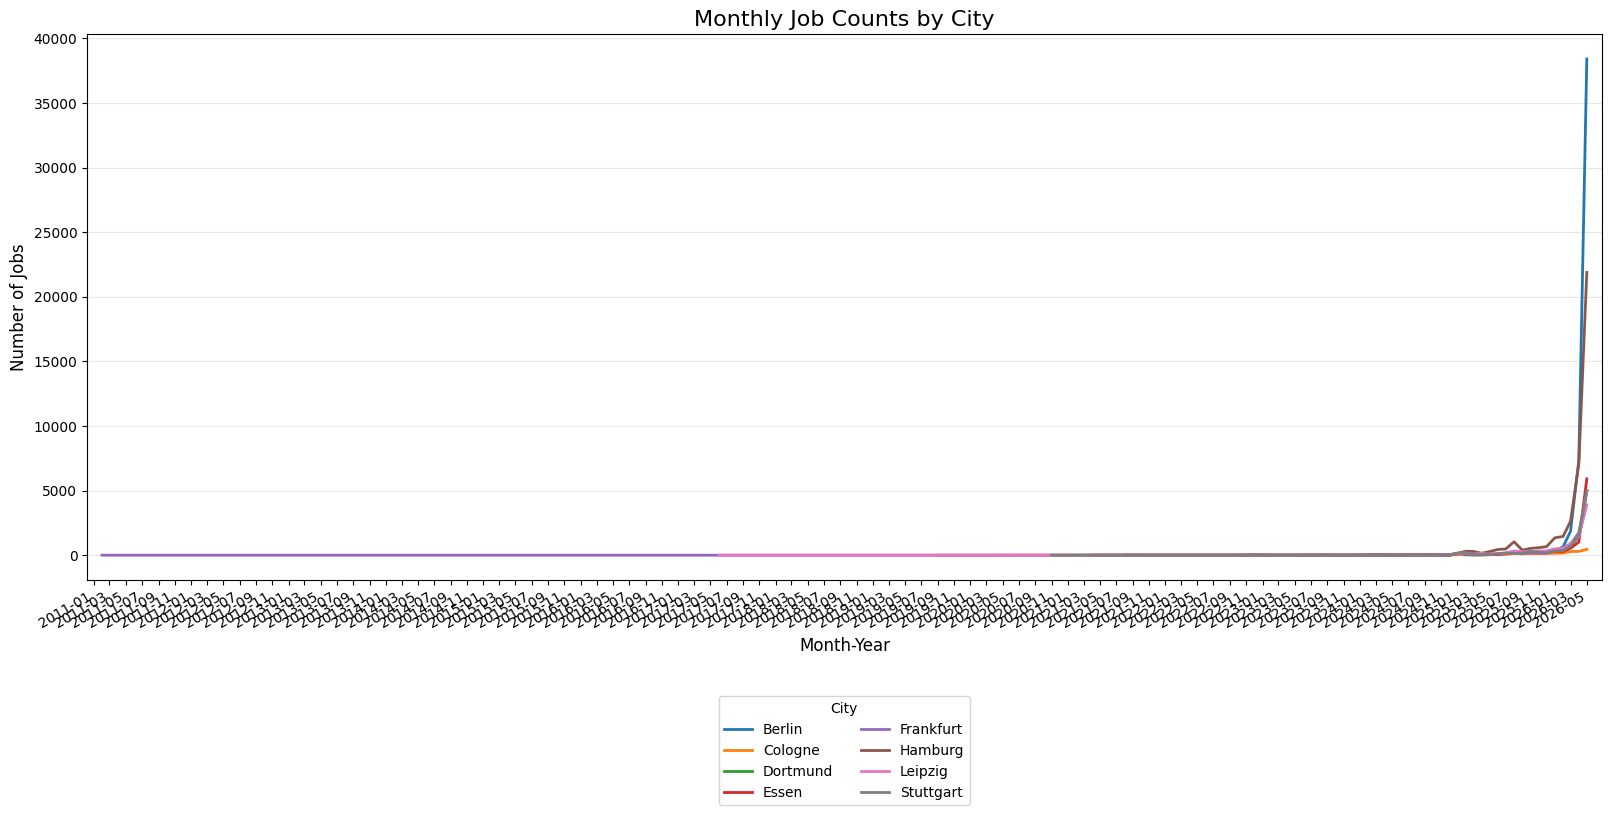

,month_start,city_label,job_count
0,2011-02-01,Frankfurt,1
1,2011-11-01,Frankfurt,1
2,2011-12-01,Frankfurt,1
3,2014-08-01,Frankfurt,1
4,2015-04-01,Frankfurt,1


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_df = jobs_df.copy()
plot_df["publication_date"] = pd.to_datetime(plot_df["publication_date"], errors="coerce")
plot_df = plot_df.dropna(subset=["publication_date", "city_label"])

# Aggregate at month-year level (not daily)
plot_df["year"] = plot_df["publication_date"].dt.year
plot_df["month"] = plot_df["publication_date"].dt.month
plot_df["month_start"] = pd.to_datetime(
    dict(year=plot_df["year"], month=plot_df["month"], day=1)
)

monthly_city_jobs = (
    plot_df.groupby(["month_start", "city_label"], as_index=False)
    .size()
    .rename(columns={"size": "job_count"})
)

fig, ax = plt.subplots(figsize=(16, 8), constrained_layout=True)
for city in sorted(monthly_city_jobs["city_label"].unique()):
    city_data = monthly_city_jobs[monthly_city_jobs["city_label"] == city]
    ax.plot(city_data["month_start"], city_data["job_count"], linewidth=2, label=city)

ax.set_title("Monthly Job Counts by City", fontsize=16)
ax.set_xlabel("Month-Year", fontsize=12)
ax.set_ylabel("Number of Jobs", fontsize=12)

# Reduce axis crowding: show one tick every 2 months and format as YYYY-MM
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.margins(x=0.01)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="City", ncol=2, bbox_to_anchor=(0.5, -0.2), loc="upper center")
plt.show()

monthly_city_jobs.head()

In [6]:
monthly_city_jobs["month_start"].min(), monthly_city_jobs["month_start"].max()

(Timestamp('2011-02-01 00:00:00'), Timestamp('2026-05-01 00:00:00'))

In [7]:
monthly_city_jobs[monthly_city_jobs["city_label"]=='Berlin'].sort_values("month_start", ascending=False).head()

,month_start,city_label,job_count
344,2026-05-01,Berlin,38400
336,2026-04-01,Berlin,7350
328,2026-03-01,Berlin,1855
320,2026-02-01,Berlin,645
312,2026-01-01,Berlin,360


In [8]:
jobs_df[jobs_df["city_label"]=='Berlin'].sort_values("publication_date", ascending=False).head()

,city_label,area_query,title,occupation,reference,employer,publication_date,postal_code,city_returned,region,lat,lon,is_industrial
0,Berlin,Berlin Mitte,Duales Studium Hotelmanagement (m/w/d),Assistent/in - Hotelmanagement,12518-0UJ2TU-27Z-S,Motel One Berlin - Hackescher Markt,2026-05-24,10179,Berlin,Berlin,52.513228,13.415724,False
20234,Berlin,Berlin Tempelhof,Mitarbeiter (in) für das Thema Erbbaurechte (d...,Betriebswirt/in (Fachschule) - Immobilien/Bach...,18024-100fe00002d23-S,Berliner Stadtgüter GmbH,2026-05-24,NaN,Berlin,Berlin,52.492683,13.402575,False
20243,Berlin,Berlin Tempelhof,NTT DATA Deutschland SE: ServiceNow Senior Sol...,IT-Berater/in,19913-3010251779573600-S,NTT DATA Deutschland SE,2026-05-24,10117,Berlin,Berlin,52.517272,13.388290,False
20242,Berlin,Berlin Tempelhof,NTT DATA Deutschland SE: SAP Finance & Control...,ERP-Berater/in - ERP-Consultant,19913-3010131779573600-S,NTT DATA Deutschland SE,2026-05-24,10117,Berlin,Berlin,52.517272,13.388290,False
20241,Berlin,Berlin Tempelhof,NTT DATA Deutschland SE: SAP AI Consultant (w/...,KI-Engineer,19913-3009911779573600-S,NTT DATA Deutschland SE,2026-05-24,10117,Berlin,Berlin,52.517272,13.388290,False


Berlin jobs with valid lat/lon/is_industrial: 50,000
         lat        lon  is_industrial
0  52.513228  13.415724          False
1  52.513228  13.415724          False
2  52.513228  13.415724           True
3  52.513228  13.415724          False
4  52.513228  13.415724          False


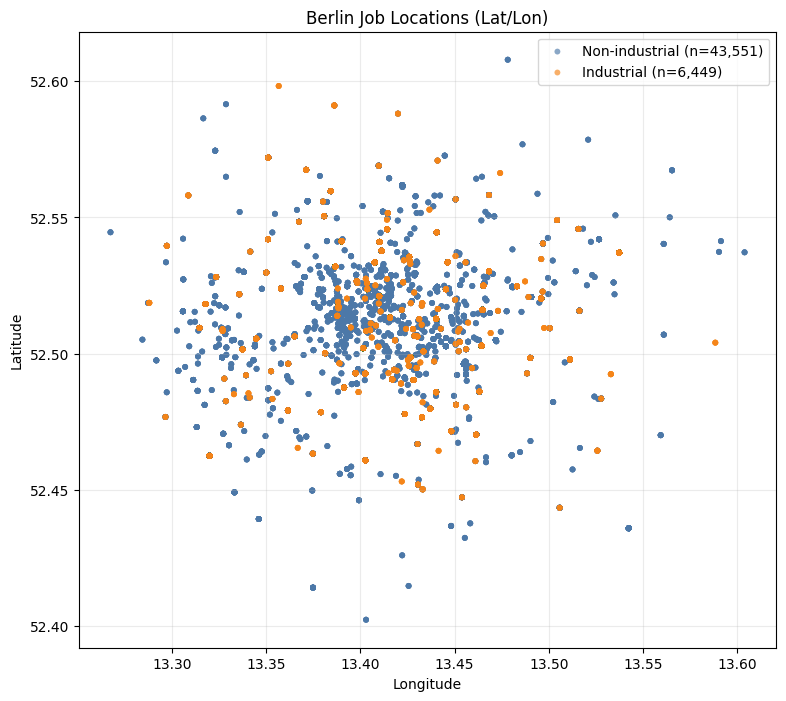

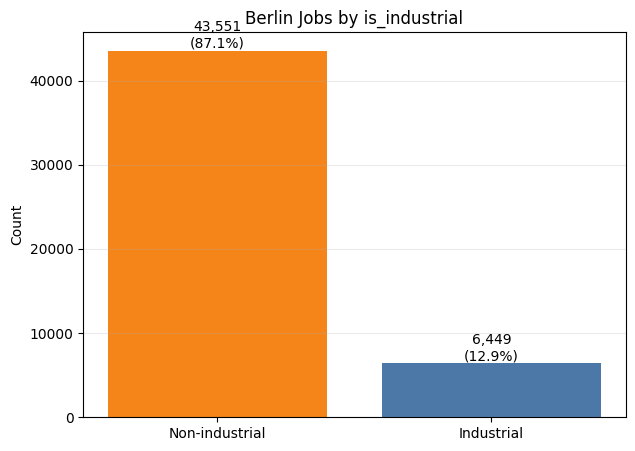

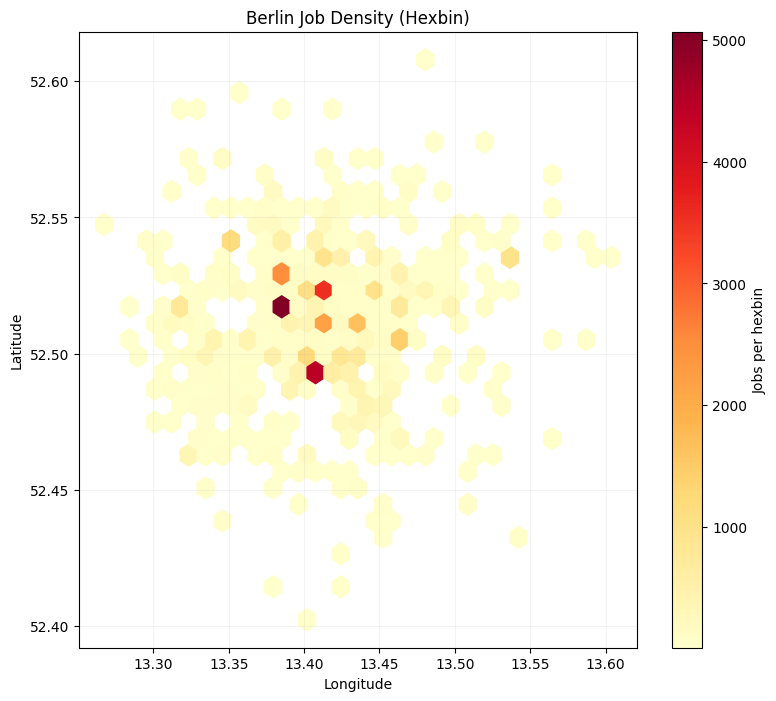

{'rows': 50000,
 'industrial_count': 6449,
 'non_industrial_count': 43551,
 'industrial_share': 0.12898,
 'lat_range': (52.40235096, 52.607889),
 'lon_range': (13.2673908, 13.603842)}

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Filter to Berlin and keep rows with coordinates + industrial flag
berlin_df = jobs_df.loc[
    (jobs_df["city_label"] == "Berlin")
    & jobs_df["lat"].notna()
    & jobs_df["lon"].notna()
    & jobs_df["is_industrial"].notna()
].copy()

berlin_df["lat"] = pd.to_numeric(berlin_df["lat"], errors="coerce")
berlin_df["lon"] = pd.to_numeric(berlin_df["lon"], errors="coerce")
berlin_df = berlin_df.dropna(subset=["lat", "lon"])

print(f"Berlin jobs with valid lat/lon/is_industrial: {len(berlin_df):,}")
print(berlin_df[["lat", "lon", "is_industrial"]].head())

if berlin_df.empty:
    raise ValueError("No Berlin rows with valid lat/lon/is_industrial were found.")

# --- Figure 1: Berlin geo-scatter (industrial vs non-industrial) ---
fig, ax = plt.subplots(figsize=(9, 8))
for flag, color, label in [
    (False, "#4C78A8", "Non-industrial"),
    (True, "#F58518", "Industrial"),
]:
    subset = berlin_df[berlin_df["is_industrial"] == flag]
    ax.scatter(
        subset["lon"],
        subset["lat"],
        s=18,
        alpha=0.65,
        c=color,
        edgecolor="none",
        label=f"{label} (n={len(subset):,})",
    )

ax.set_title("Berlin Job Locations (Lat/Lon)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

# --- Figure 2: Industrial share in Berlin ---
share = (
    berlin_df["is_industrial"]
    .value_counts(dropna=False)
    .rename(index={True: "Industrial", False: "Non-industrial"})
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(share.index, share.values, color=["#F58518", "#4C78A8"])
ax.set_title("Berlin Jobs by is_industrial")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)

for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h,
        f"{int(h):,}\n({h / len(berlin_df):.1%})",
        ha="center",
        va="bottom",
    )

plt.show()

# --- Figure 3: Spatial density (hexbin) for Berlin jobs ---
fig, ax = plt.subplots(figsize=(9, 8))
hex_plot = ax.hexbin(
    berlin_df["lon"],
    berlin_df["lat"],
    gridsize=30,
    cmap="YlOrRd",
    mincnt=1,
)
cb = fig.colorbar(hex_plot, ax=ax)
cb.set_label("Jobs per hexbin")
ax.set_title("Berlin Job Density (Hexbin)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.15)
plt.show()

# Quick numeric summary for reuse
berlin_summary = {
    "rows": int(len(berlin_df)),
    "industrial_count": int((berlin_df["is_industrial"] == True).sum()),
    "non_industrial_count": int((berlin_df["is_industrial"] == False).sum()),
    "industrial_share": float((berlin_df["is_industrial"] == True).mean()),
    "lat_range": (float(berlin_df["lat"].min()), float(berlin_df["lat"].max())),
    "lon_range": (float(berlin_df["lon"].min()), float(berlin_df["lon"].max())),
}

berlin_summary

Cities found: 8
['Berlin', 'Cologne', 'Dortmund', 'Essen', 'Frankfurt', 'Hamburg', 'Leipzig', 'Stuttgart']


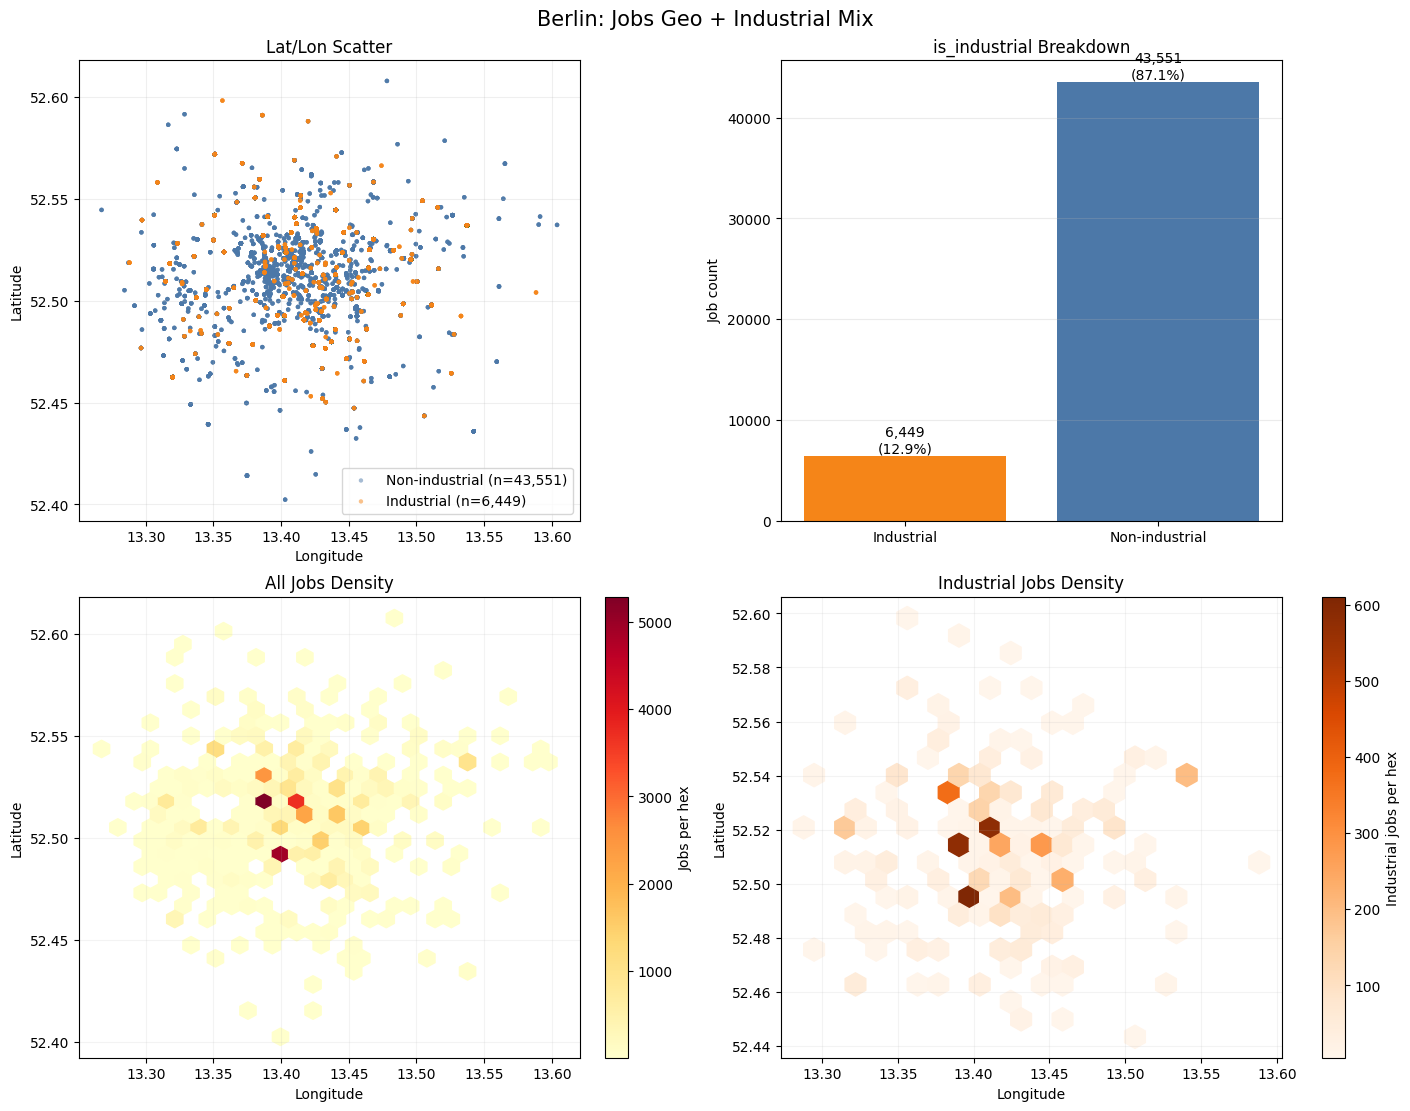

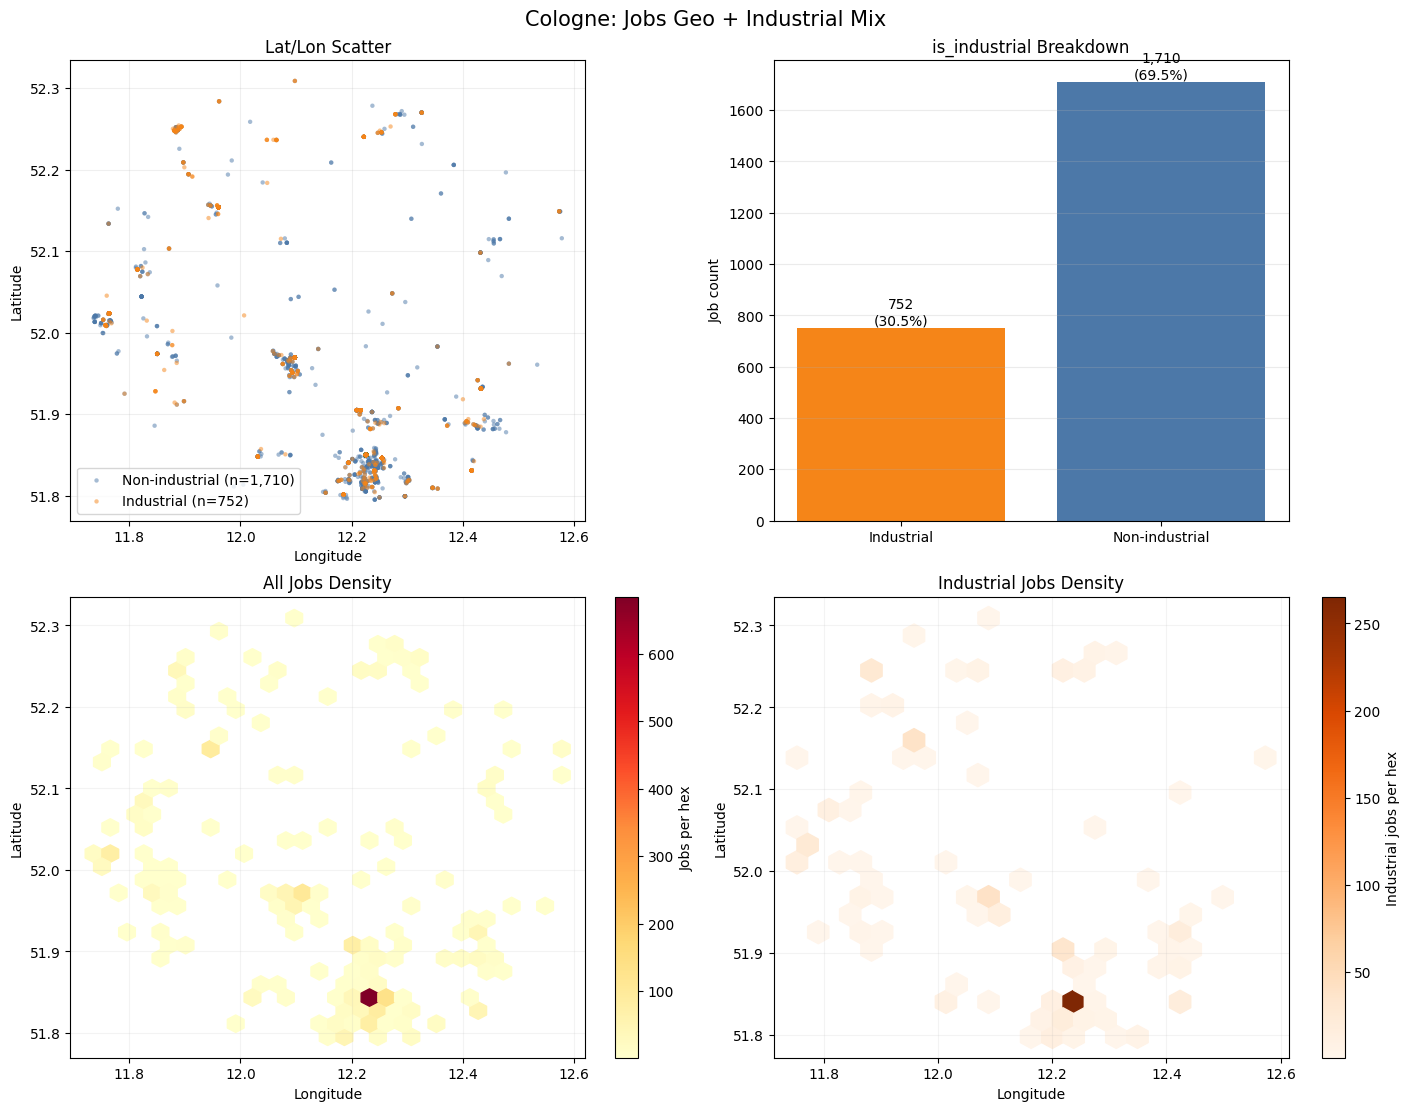

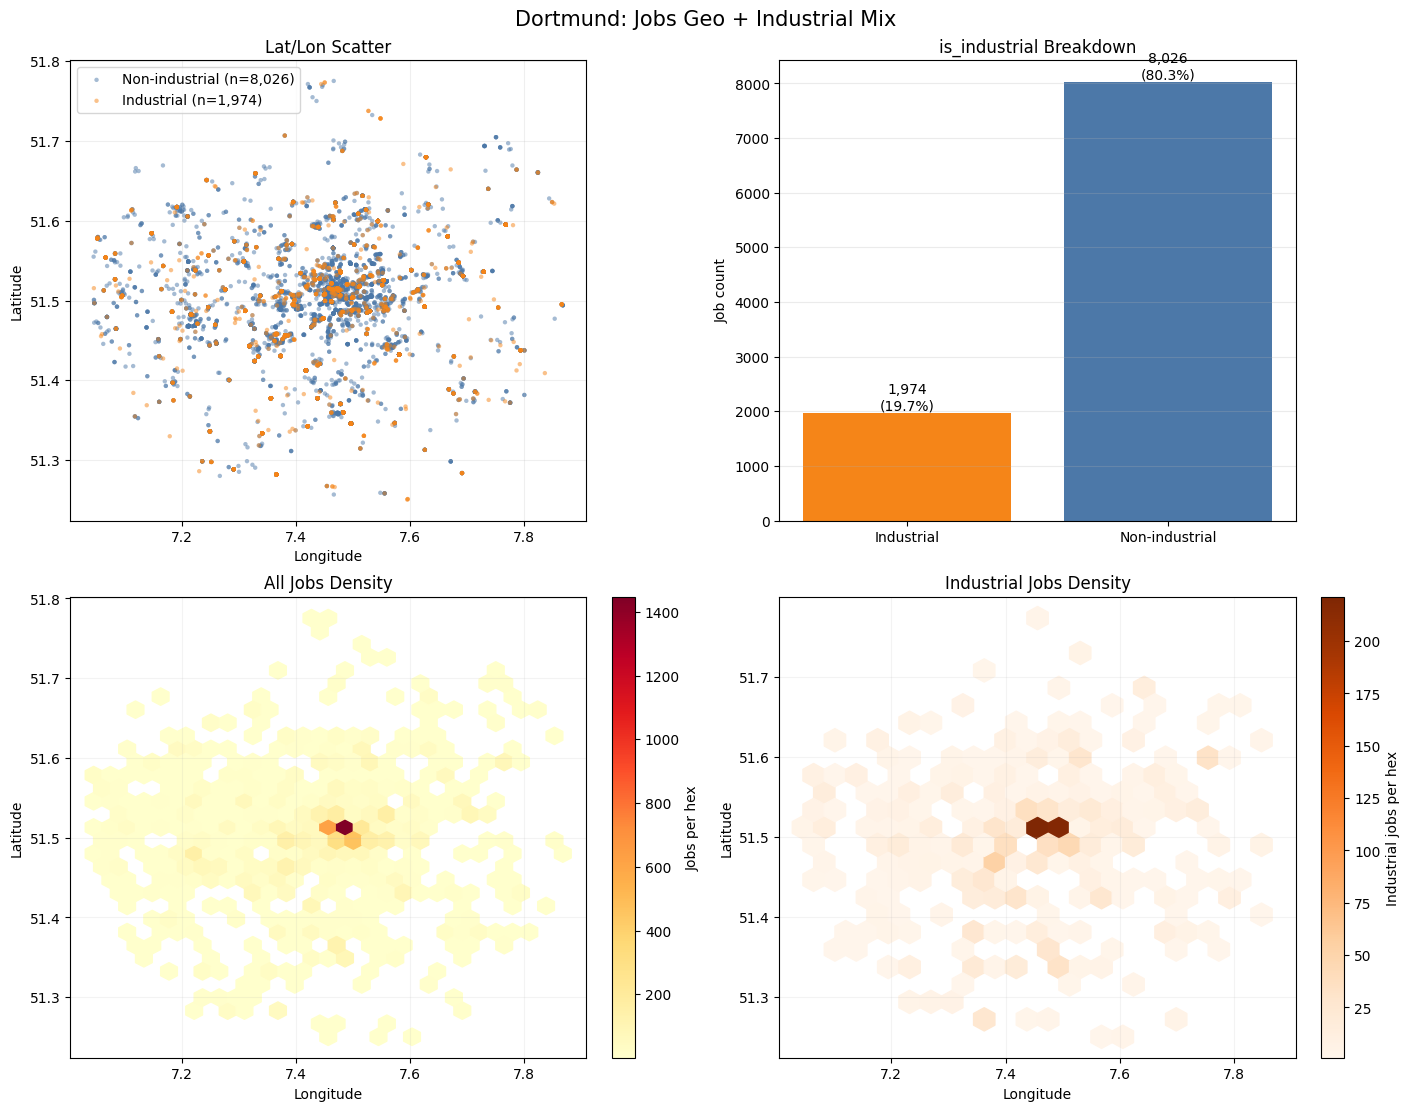

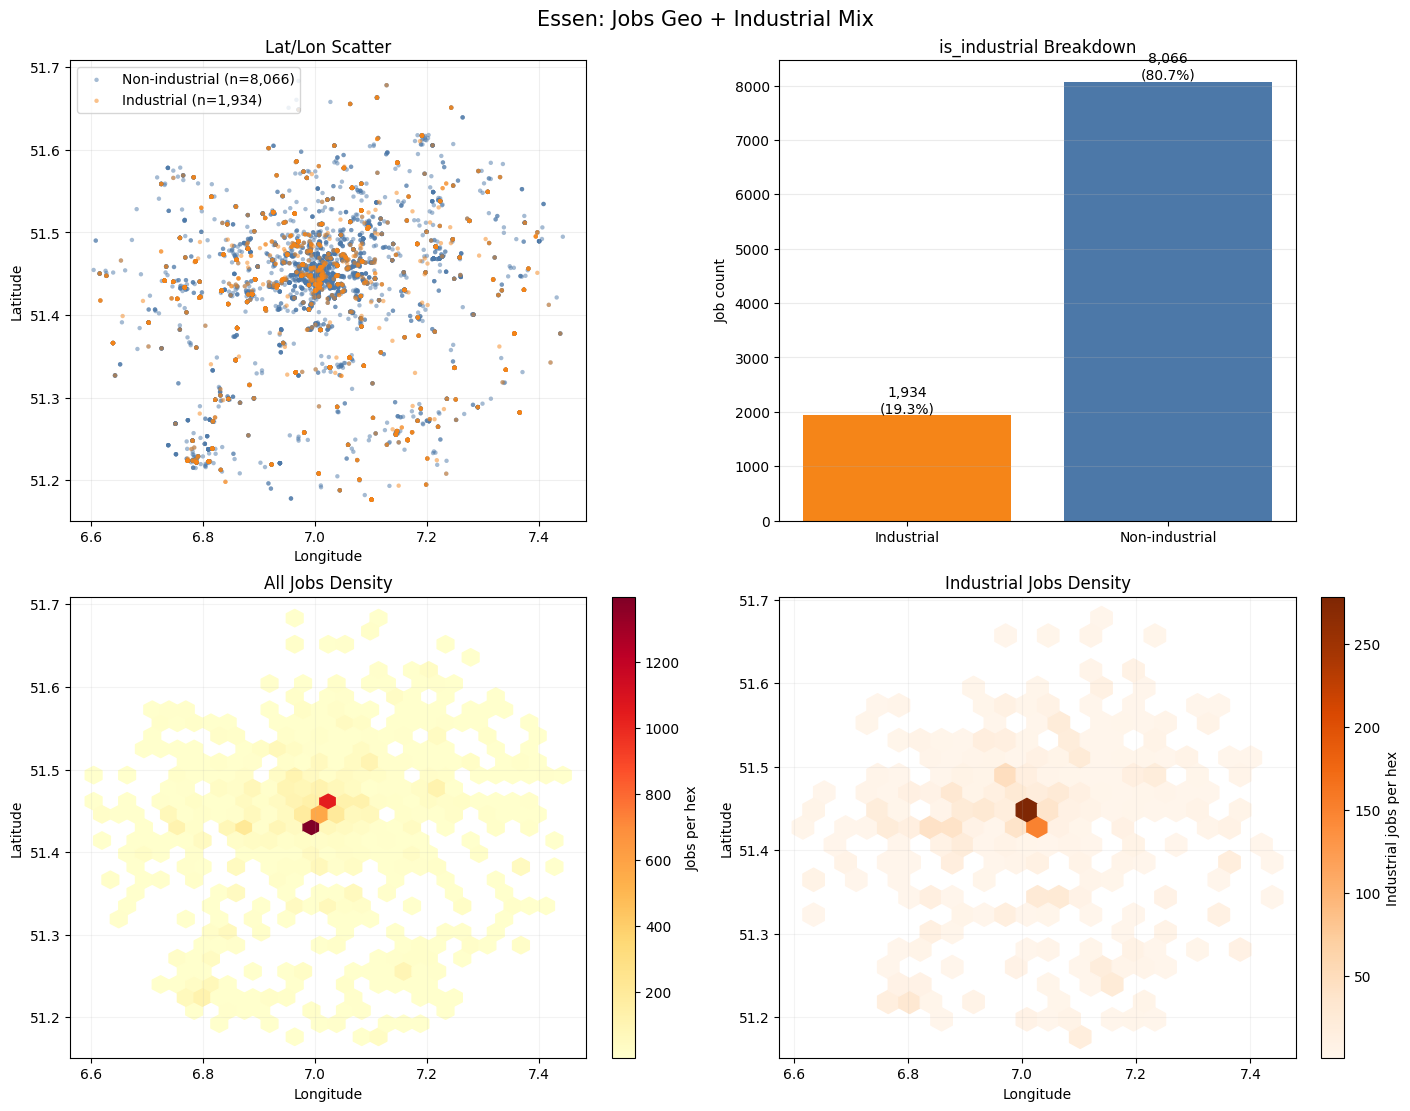

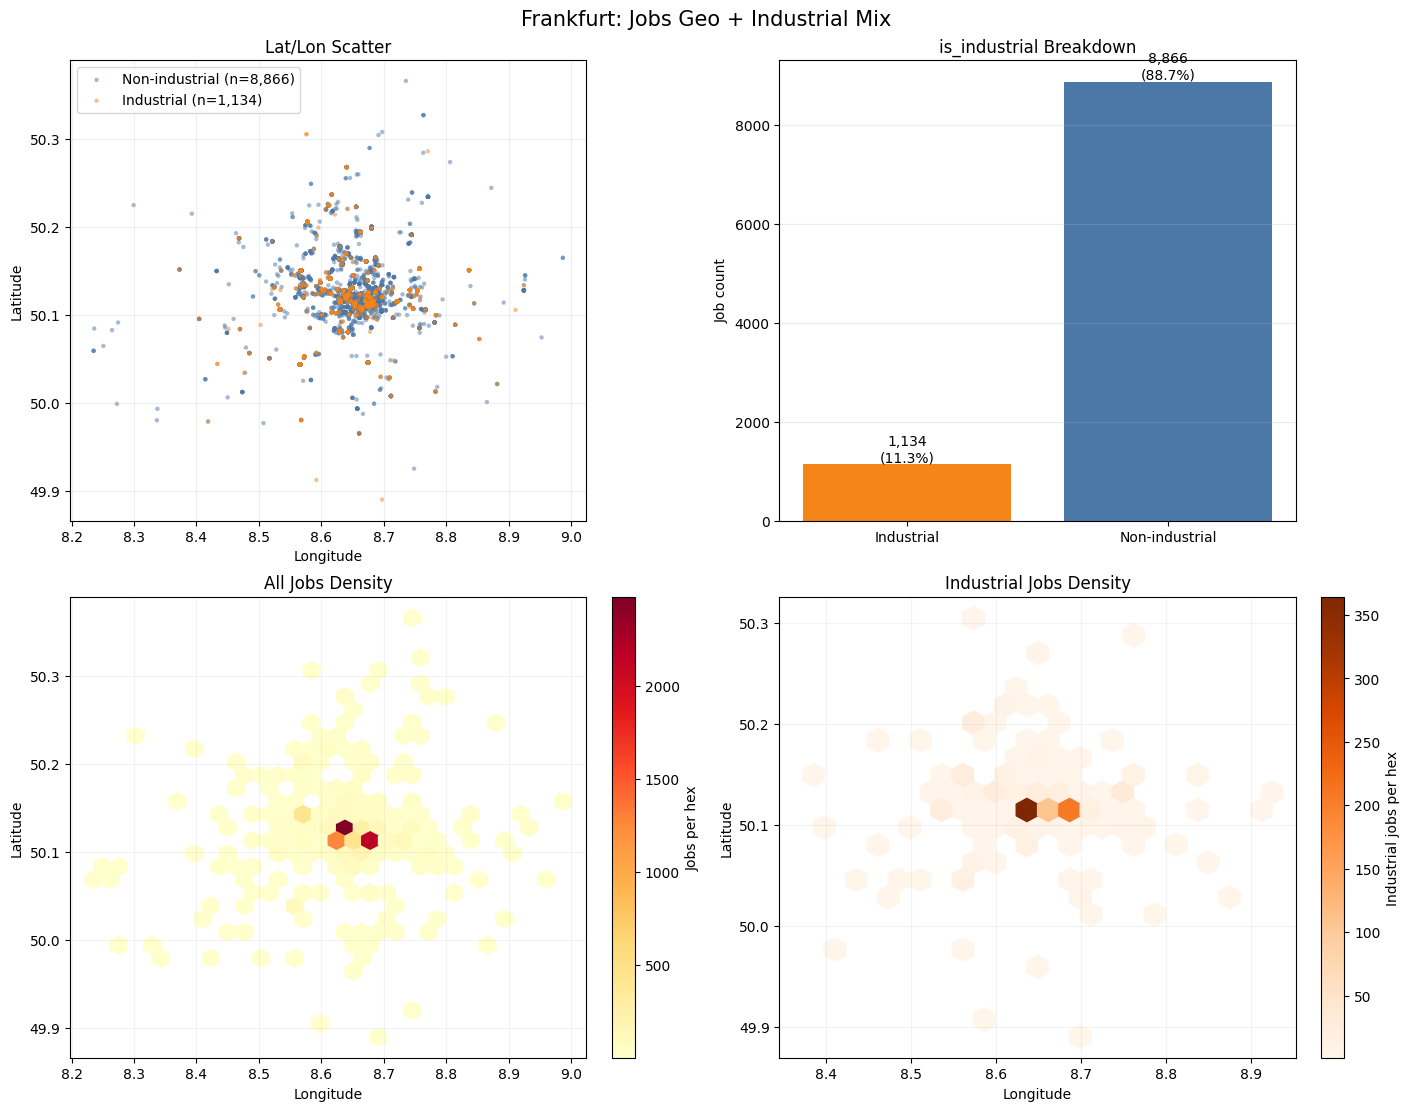

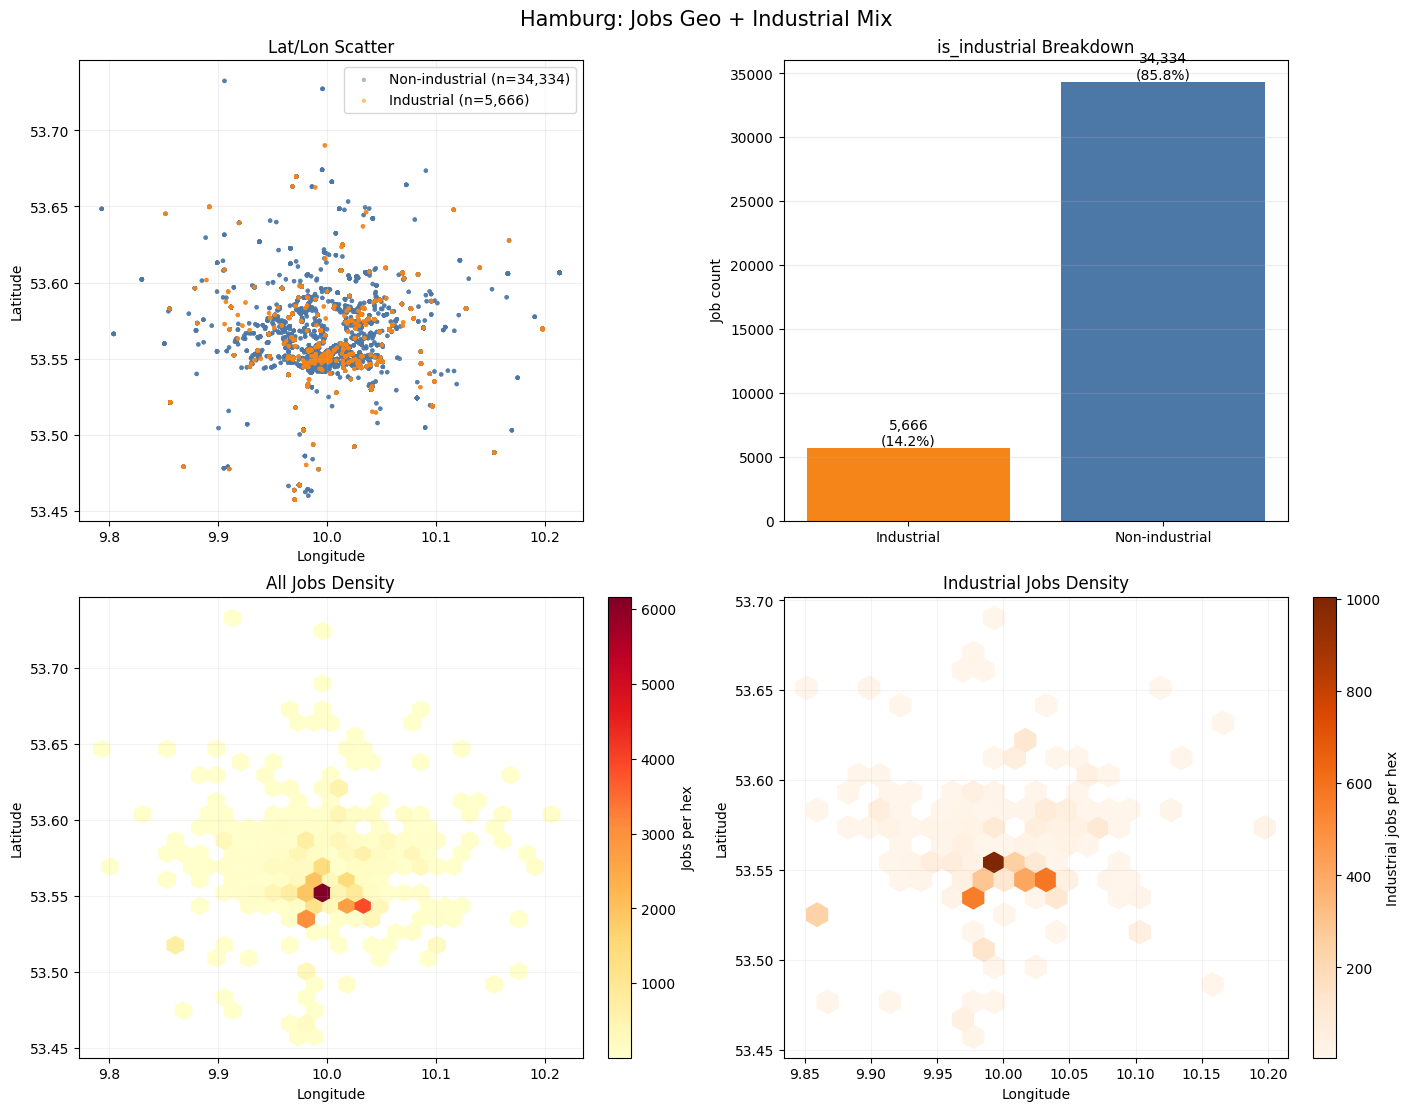

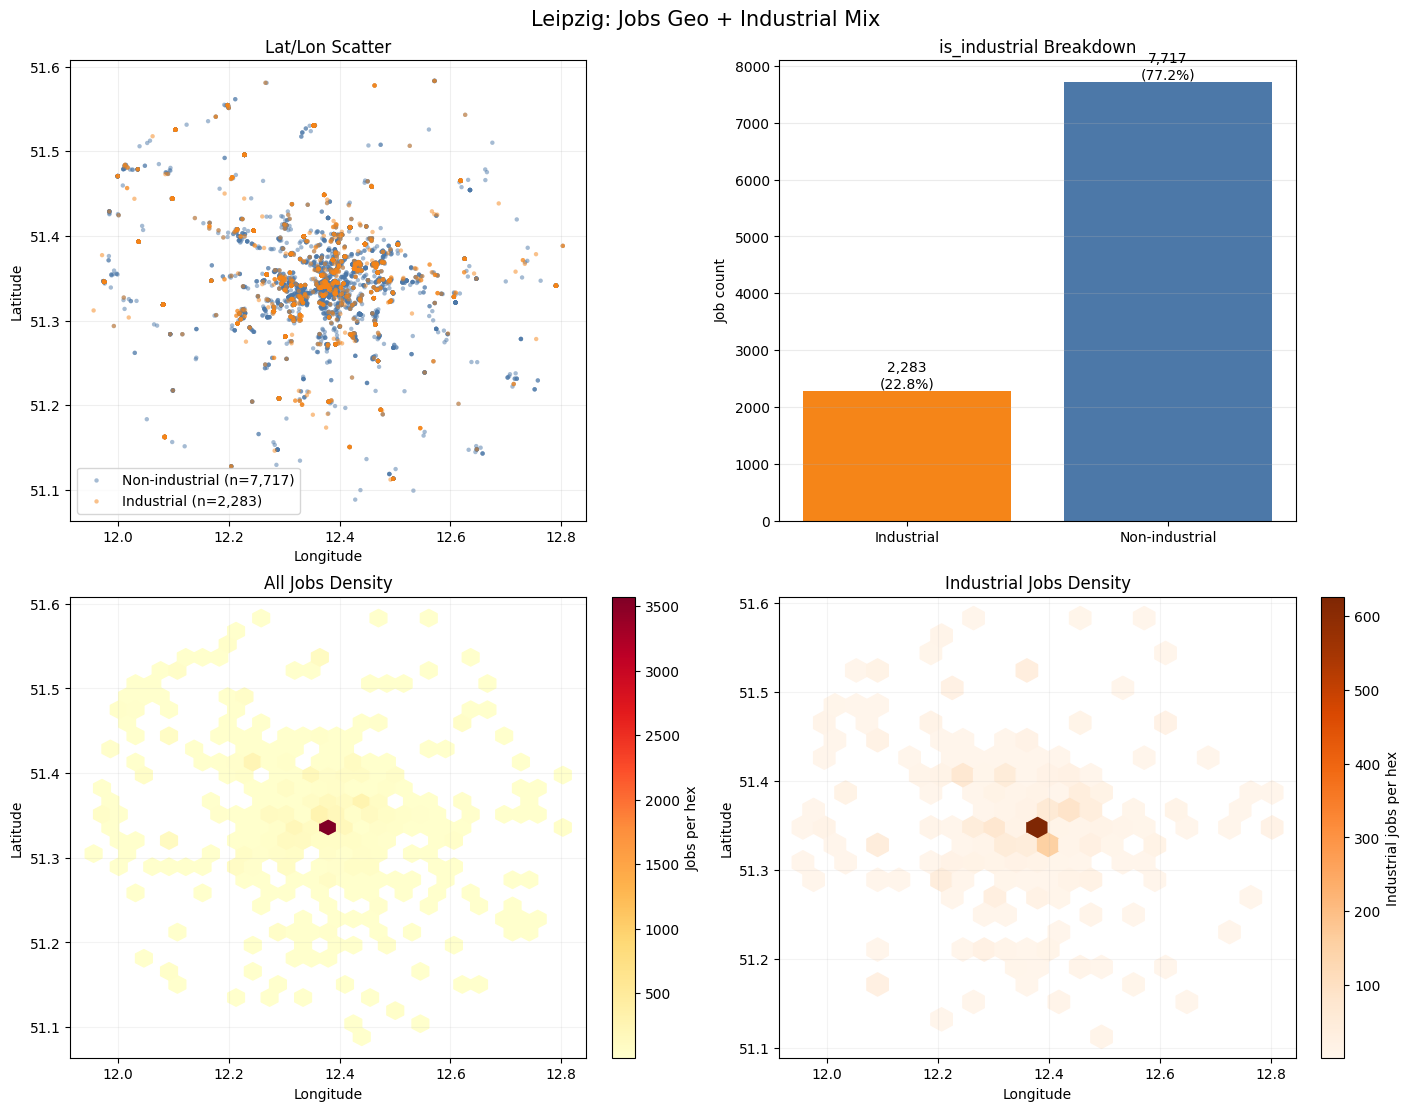

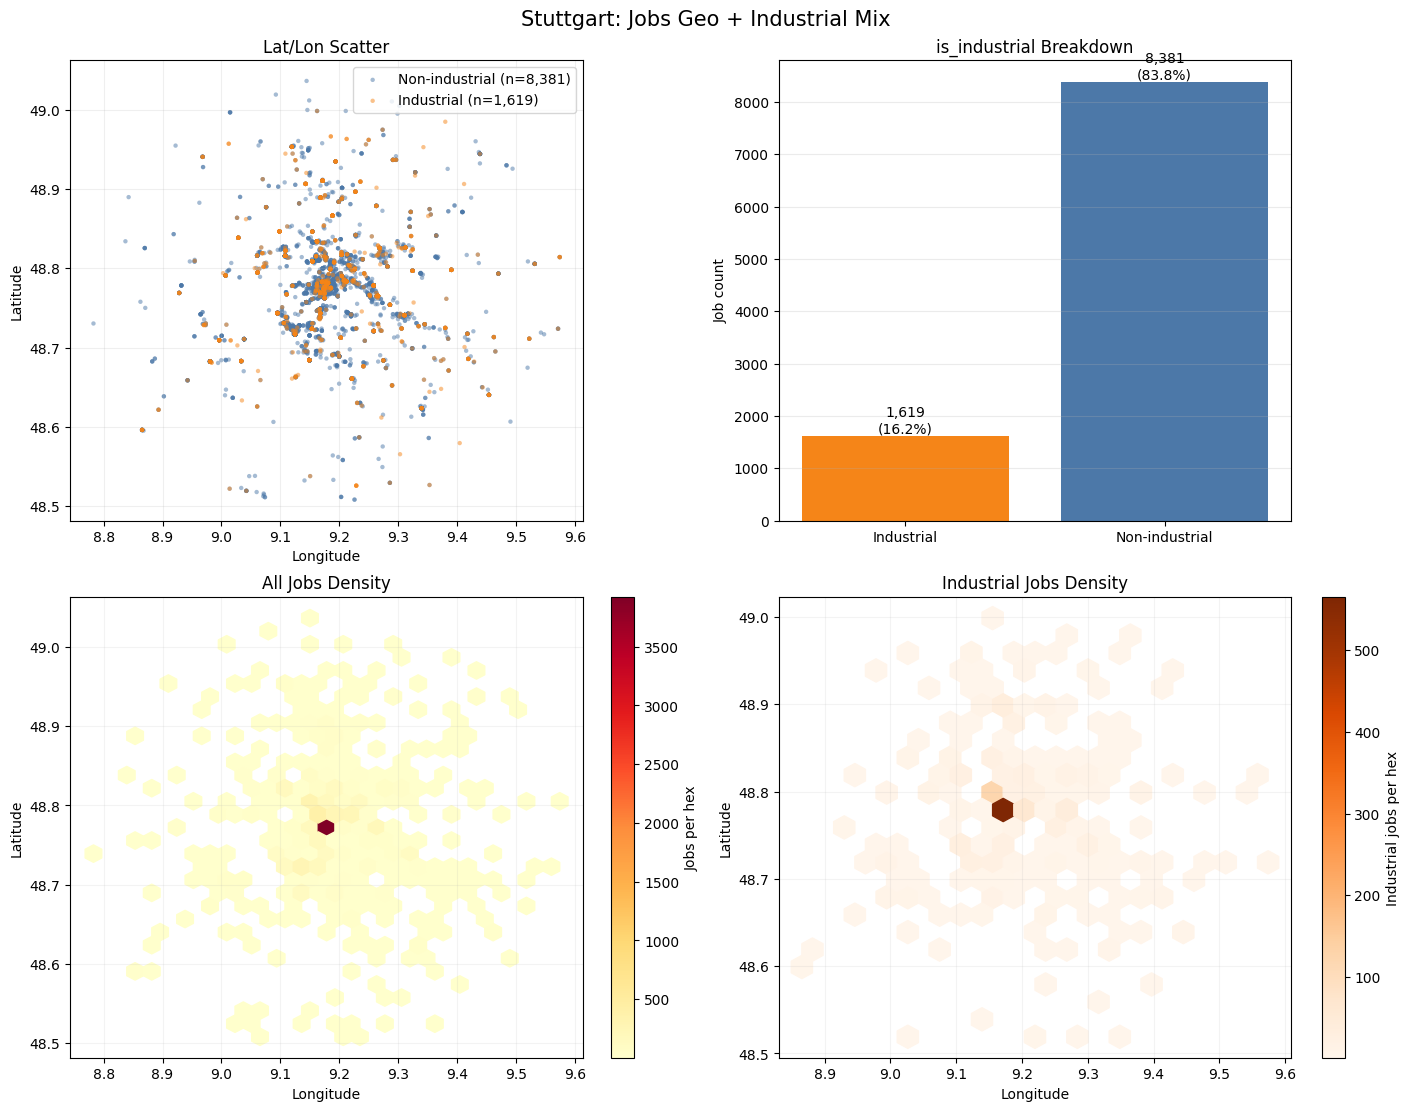

,city_label,rows,industrial_count,non_industrial_count,industrial_share,lat_min,lat_max,lon_min,lon_max
0,Berlin,50000,6449,43551,0.128980,52.402351,52.607889,13.267391,13.603842
5,Hamburg,40000,5666,34334,0.141650,53.457319,53.732502,9.792865,10.213365
3,Essen,10000,1934,8066,0.193400,51.176418,51.683293,6.605316,7.442708
2,Dortmund,10000,1974,8026,0.197400,51.250392,51.775236,7.045416,7.868052
6,Leipzig,10000,2283,7717,0.228300,51.088626,51.582996,11.956369,12.802874
4,Frankfurt,10000,1134,8866,0.113400,49.889928,50.365377,8.235404,8.986816
7,Stuttgart,10000,1619,8381,0.161900,48.508011,49.036572,8.782737,9.574051
1,Cologne,2462,752,1710,0.305443,51.795271,52.308930,11.736185,12.577491


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Keep only rows with usable fields for mapping/classification
city_plot_df = jobs_df.loc[
    jobs_df["city_label"].notna()
    & jobs_df["lat"].notna()
    & jobs_df["lon"].notna()
    & jobs_df["is_industrial"].notna()
].copy()

city_plot_df["lat"] = pd.to_numeric(city_plot_df["lat"], errors="coerce")
city_plot_df["lon"] = pd.to_numeric(city_plot_df["lon"], errors="coerce")
city_plot_df = city_plot_df.dropna(subset=["lat", "lon"])

city_labels = sorted(city_plot_df["city_label"].unique())
print(f"Cities found: {len(city_labels)}")
print(city_labels)

city_summaries = []

for city in city_labels:
    city_df = city_plot_df[city_plot_df["city_label"] == city].copy()

    if city_df.empty:
        continue

    industrial_count = int((city_df["is_industrial"] == True).sum())
    non_industrial_count = int((city_df["is_industrial"] == False).sum())
    industrial_share = industrial_count / len(city_df)

    city_summaries.append(
        {
            "city_label": city,
            "rows": int(len(city_df)),
            "industrial_count": industrial_count,
            "non_industrial_count": non_industrial_count,
            "industrial_share": industrial_share,
            "lat_min": float(city_df["lat"].min()),
            "lat_max": float(city_df["lat"].max()),
            "lon_min": float(city_df["lon"].min()),
            "lon_max": float(city_df["lon"].max()),
        }
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
    fig.suptitle(f"{city}: Jobs Geo + Industrial Mix", fontsize=15)

    # (1) Geo scatter by industrial flag
    ax = axes[0, 0]
    for flag, color, label in [
        (False, "#4C78A8", "Non-industrial"),
        (True, "#F58518", "Industrial"),
    ]:
        subset = city_df[city_df["is_industrial"] == flag]
        ax.scatter(
            subset["lon"],
            subset["lat"],
            s=10,
            alpha=0.5,
            c=color,
            edgecolor="none",
            label=f"{label} (n={len(subset):,})",
        )
    ax.set_title("Lat/Lon Scatter")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")

    # (2) Count + share bar
    ax = axes[0, 1]
    bar_labels = ["Industrial", "Non-industrial"]
    bar_values = [industrial_count, non_industrial_count]
    bars = ax.bar(bar_labels, bar_values, color=["#F58518", "#4C78A8"])
    ax.set_title("is_industrial Breakdown")
    ax.set_ylabel("Job count")
    ax.grid(axis="y", alpha=0.25)
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{int(h):,}\n({h / len(city_df):.1%})",
            ha="center",
            va="bottom",
        )

    # (3) Density of all jobs
    ax = axes[1, 0]
    hb_all = ax.hexbin(
        city_df["lon"],
        city_df["lat"],
        gridsize=28,
        cmap="YlOrRd",
        mincnt=1,
    )
    fig.colorbar(hb_all, ax=ax, label="Jobs per hex")
    ax.set_title("All Jobs Density")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.15)

    # (4) Density of industrial-only jobs
    ax = axes[1, 1]
    industrial_df = city_df[city_df["is_industrial"] == True]
    if industrial_df.empty:
        ax.text(0.5, 0.5, "No industrial jobs", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Industrial Jobs Density")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(alpha=0.15)
    else:
        hb_ind = ax.hexbin(
            industrial_df["lon"],
            industrial_df["lat"],
            gridsize=22,
            cmap="Oranges",
            mincnt=1,
        )
        fig.colorbar(hb_ind, ax=ax, label="Industrial jobs per hex")
        ax.set_title("Industrial Jobs Density")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(alpha=0.15)

    plt.show()

city_summary_df = pd.DataFrame(city_summaries).sort_values("rows", ascending=False)
city_summary_df